In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/transformer-gpt-assignment (1).zip" /content/transformer-gpt-assignment.zip
!unzip -q /content/transformer-gpt-assignment.zip -d /content/
%cd /content/transformer-gpt-assignment
!pip install -q -r requirements.txt

/content/transformer-gpt-assignment


In [3]:
!python -m pytest -q

.....................                                                    [100%]
21 passed in 15.34s


In [4]:
!python -m src.train --overfit

run: tiny_gpt | device: cuda | params: 3,192,832 | vocab: 65
model config: {'vocab_size': 65, 'context_length': 128, 'd_model': 256, 'n_heads': 4, 'n_layers': 4, 'ffn_dim': None, 'dropout': 0.0, 'pos_type': 'sinusoidal', 'tie_weights': False}
[overfit] step    0 | loss 4.2719
[overfit] step   25 | loss 2.4726
[overfit] step   50 | loss 1.5872
[overfit] step   75 | loss 0.5560
[overfit] step  100 | loss 0.1197
[overfit] step  125 | loss 0.0380
[overfit] step  150 | loss 0.0250
[overfit] step  175 | loss 0.0206
[overfit] step  200 | loss 0.0184
[overfit] step  225 | loss 0.0172
[overfit] step  250 | loss 0.0164
[overfit] step  275 | loss 0.0160
[overfit] step  299 | loss 0.0156
overfit test: loss 4.2719 -> 0.0156


In [5]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

True Tesla T4


In [6]:
!python -m src.train --config configs/tiny_gpt.yaml

run: tiny_gpt | device: cuda | params: 3,192,832 | vocab: 65
model config: {'vocab_size': 65, 'context_length': 128, 'd_model': 256, 'n_heads': 4, 'n_layers': 4, 'ffn_dim': None, 'dropout': 0.1, 'pos_type': 'sinusoidal', 'tie_weights': False}
step     0 | train 4.2715 | val 4.2718 | lr 3.00e-06
--- sample @ step 0 ---

?qC;xbRkRZkNwl'wfNZTxi-lL-eHRK
bH!YeCNbBbeA!He.-SGgJ-3IS?B??gLTa
h!bYVnJthgfNuwK&BMxv.t?VF dtl!SZaLeW?wCgMPgR.!,fDEZaYuxzCINuTZYVR&&LMtevCiazvB!!&V!?xCnl!lN!RaegHixYe-?RngmiK;lxPqHmGiZrQGbttSXH.;qWJ J
---------------------------
step   250 | train 2.2468 | val 2.2558 | lr 2.99e-04
step   500 | train 1.9441 | val 2.0258 | lr 2.96e-04
step   750 | train 1.7638 | val 1.8977 | lr 2.88e-04
step  1000 | train 1.6490 | val 1.8211 | lr 2.78e-04
--- sample @ step 1000 ---


DUKE VINCENTIO:

Rome preplain them:
Look good be the not I lord in my chome.

BULIZOKET:
Gainst so, rage and how name three cance countent a wartch.

PAULINE:
An that man the should france hall perc
---------

In [7]:
!python -m pytest -q

.....................                                                    [100%]
21 passed in 5.11s


In [8]:
!python -m src.generate --prompt "ROMEO:" --max-new-tokens 200 --temperature 0.8

Prompt: ROMEO:
Generated: ROMEO:
Think our peers are to-night.

QUEEN MARGARET:
The duke of Lancaster Souls; whom will you speak.

GLOUCESTER:

Clown:
And thou see him to know me all the ears,
Make the here looks to contrave your ho
model parameters: 3.19M
context length: 128
temperature: 0.8


In [9]:
from google.colab import files
files.download('checkpoints/tiny_gpt.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

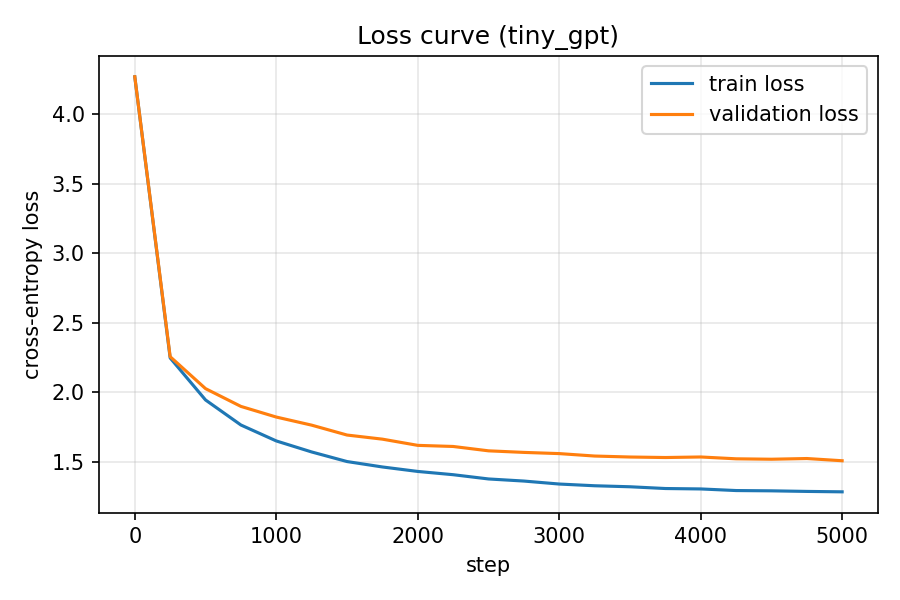

In [10]:
from IPython.display import Image
Image('outputs/figures/loss_tiny_gpt.png')

In [11]:
!python -m src.generate --prompt "ROMEO:" --max-new-tokens 200 --temperature 0.8 --seed 1
!python -m src.generate --prompt "To be, or not to be" --max-new-tokens 200 --temperature 0.8 --seed 1
!python -m src.generate --prompt "First Citizen:" --max-new-tokens 200 --temperature 0.8 --seed 1

Prompt: ROMEO:
Generated: ROMEO:
If yet my heart is uncle.

MENENIUS:
My gracious good lords,
Have thoughts words of these was and finds
An over ribred us your crown his faults
And bosom, we will not be mine else and hearts,
That sh
model parameters: 3.19M
context length: 128
temperature: 0.8
Prompt: To be, or not to be
Generated: To be, or not to be my meaning soldiers.
She says you, sir, you be a gone, he's sea:
Come your poor is these bosoms:--I now by help,
Three did still me which I now jest,
And see with the brooks of right of your hands,
T
model parameters: 3.19M
context length: 128
temperature: 0.8
Prompt: First Citizen:
Generated: First Citizen:
If yet my heart is uncle.

MENENIUS:
My lord, and my sun such sorrow is the soul,
Yourself marking in the body tribunes thyself.

First Senator:
Why, sir, we will not be mine else and leap to
That sh
model parameters: 3.19M
context length: 128
temperature: 0.8


In [12]:
!python -m experiments.evaluate
!python -m experiments.attention_visualization --layer -1
!python -m experiments.hand_calculation
!python -m experiments.architecture_evidence
!python -m experiments.mlm_vs_clm
!python -m experiments.seq_vs_parallel

checkpoint: checkpoints/tiny_gpt.pt
train loss: 1.2831
val loss:   1.5154
val perplexity: 4.55

=== 5 samples (temperature=0.8, top_k=40) ===
--- prompt 1: 'ROMEO:' ---
ROMEO:
Whose stirs stayes presently may and one private to be
my death; but thou dost right known such before:
Ancient that I can in love that must the mine.

DUKE OF AUMERLE:
And soon God stop with me but the children of himself,
So say the nature, as we say there be orason,
And strength upon our presenc

--- prompt 2: 'To be, or not to be' ---
To be, or not to be a more banish'd.

GLOUCESTER:
I am not a wife!

DERBY:
Then be dreams, thou that the house the maid,
Stand what fear hath not a bitter shall enforce
That boy'd his death, and what his fathers?
That hath all the eyes of the possesess string of
thy kedgess to my pride and a words, strange
And poor bu

--- prompt 3: 'First Citizen:\n' ---
First Citizen:
She is be pat one which to his own and safe's grief
The voice of gentle are death; and where?

POLIXENES:
I ca

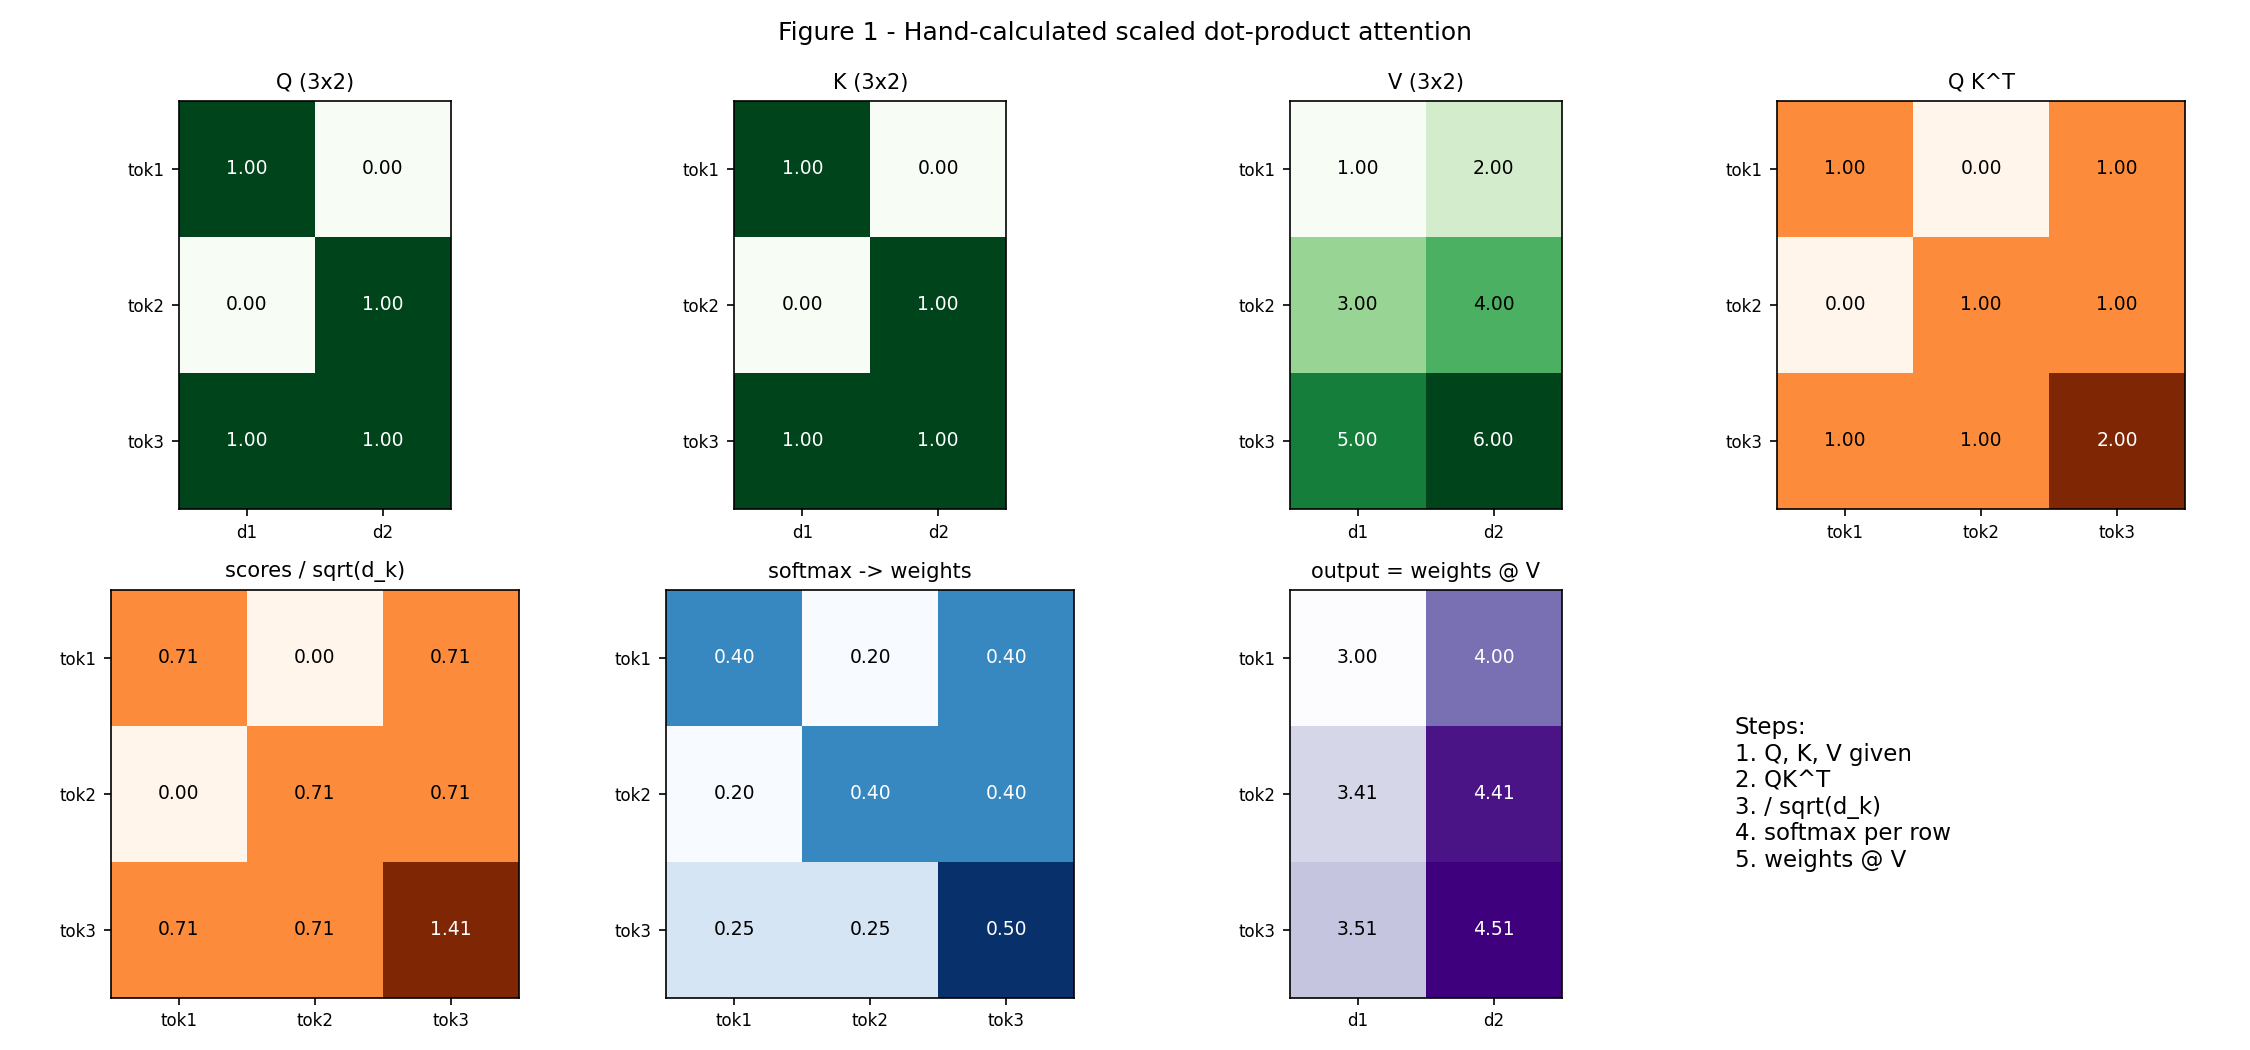

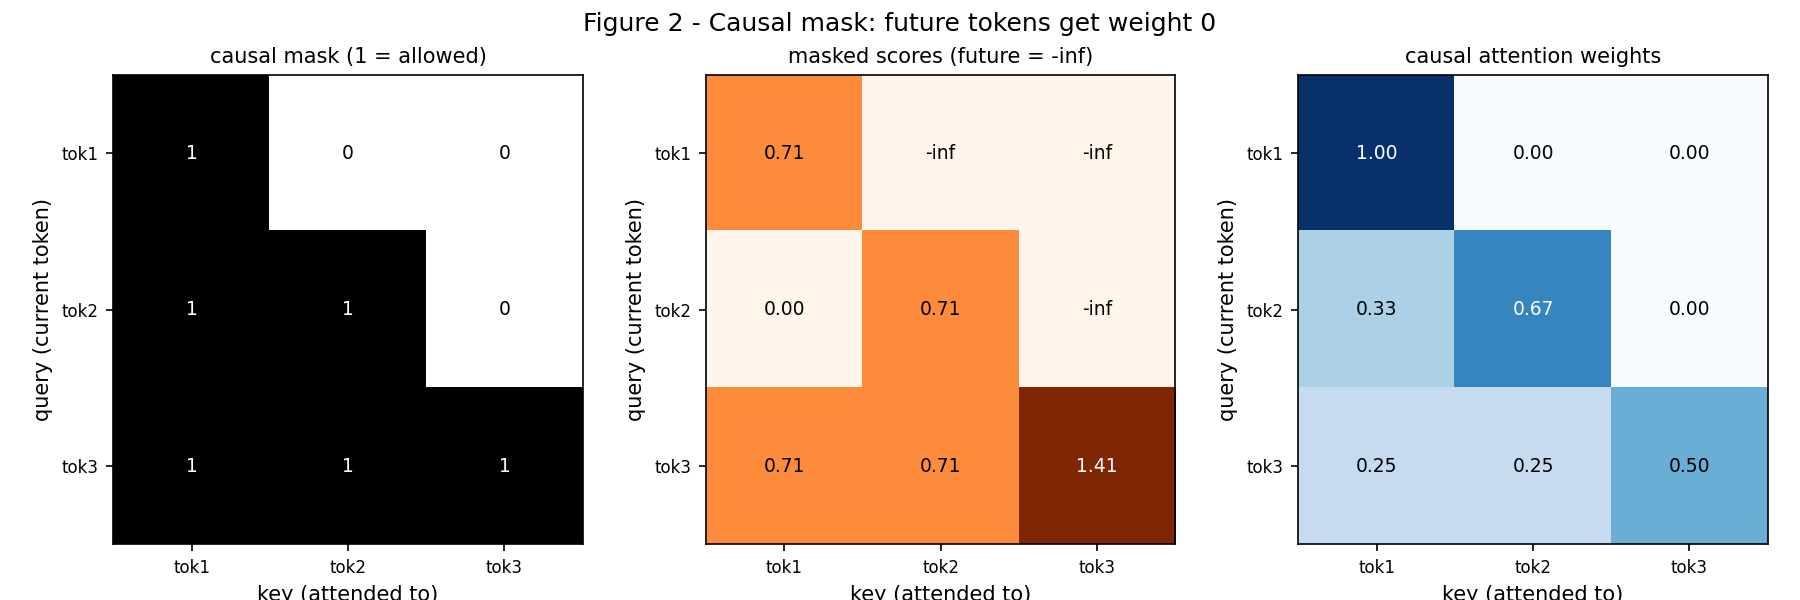

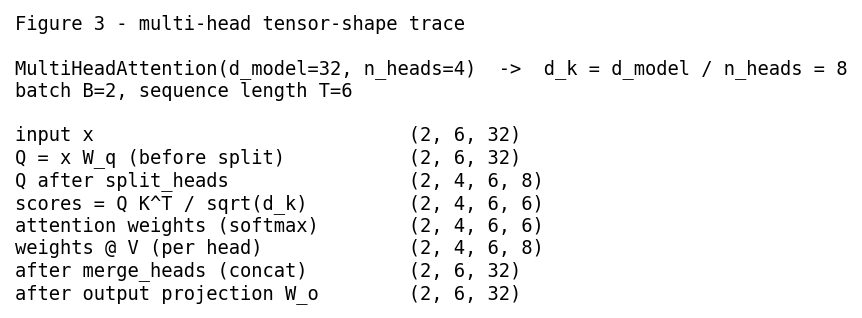

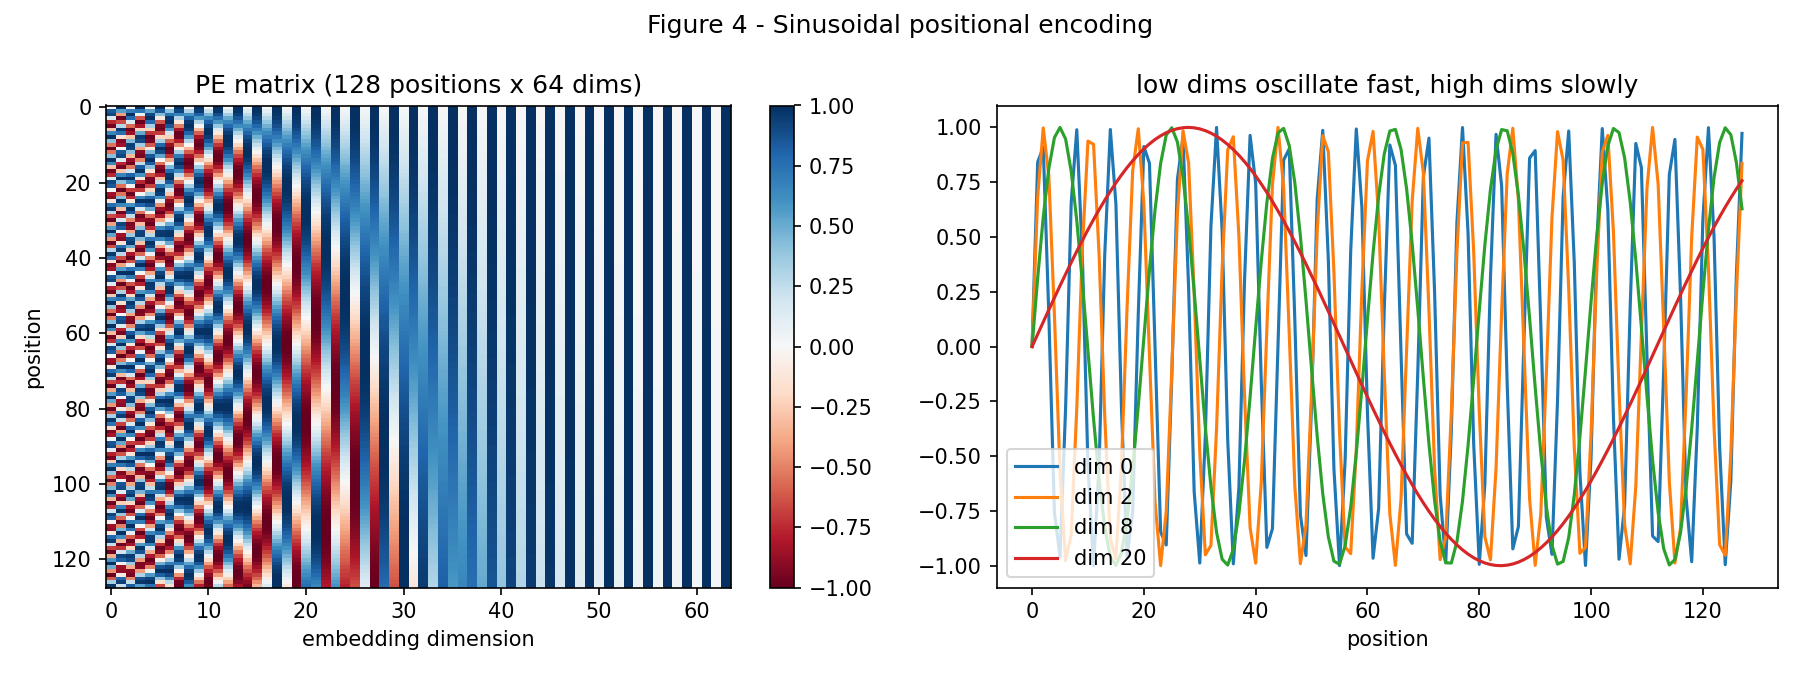

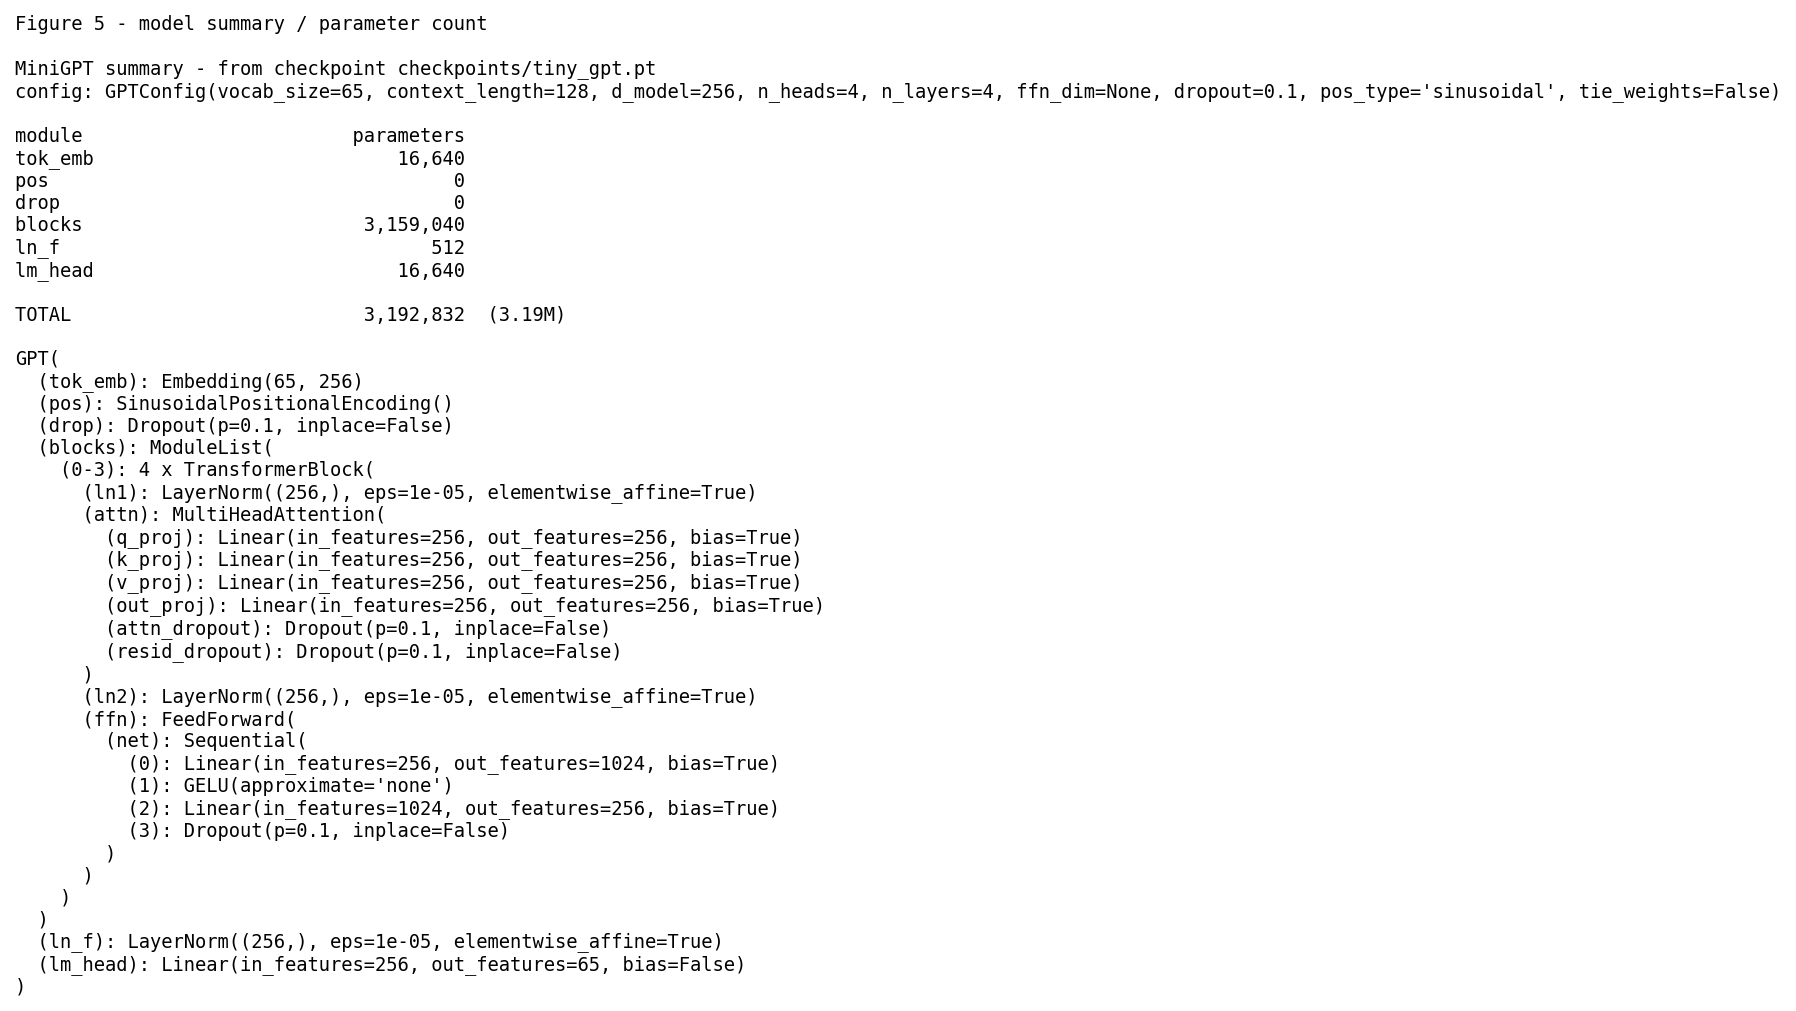

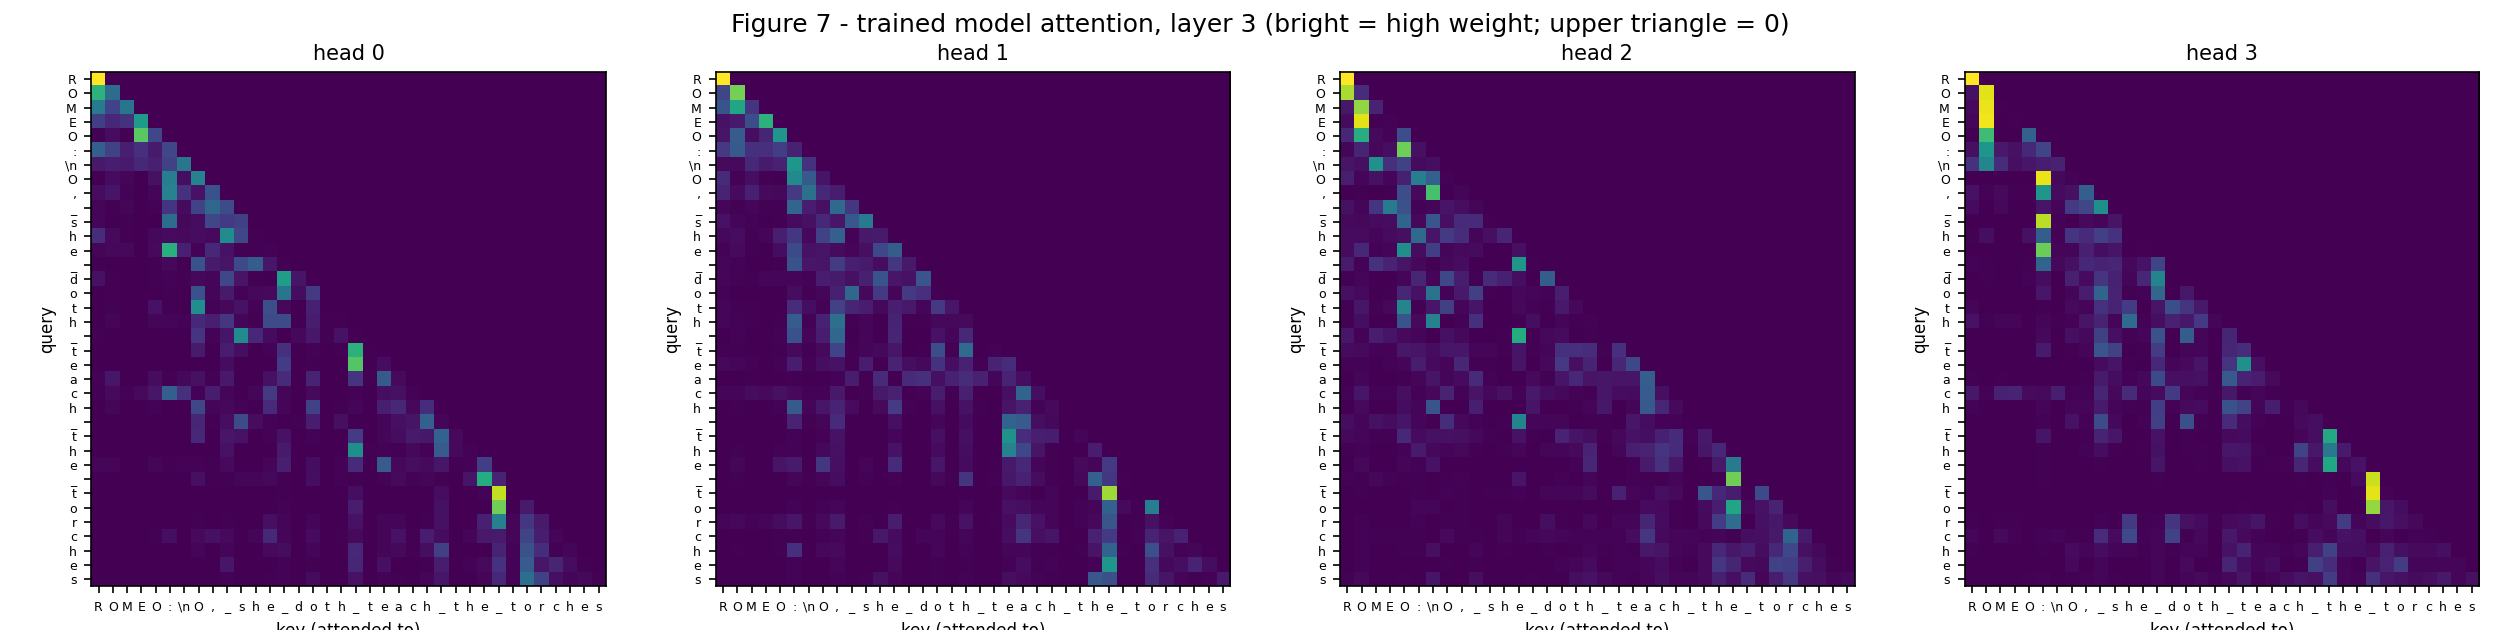

In [13]:
from IPython.display import Image, display
for f in ['fig1_hand_attention','fig2_causal_mask','fig3_multihead_shapes','fig4_positional_encoding','fig5_model_summary','fig7_attention_layer3']:
    display(Image(f'outputs/figures/{f}.png'))

In [14]:
!python -m experiments.ablation --experiments depth heads context --steps 2000
!cat outputs/logs/ablation_table.md


>>> depth = 2
{'experiment': 'depth', 'value': 2, 'params': 1613312, 'train_loss': 1.6524, 'val_loss': 1.8202, 'perplexity': 6.17, 'train_time_s': 87.5, 'tokens_per_s': 187213, 'peak_mem_mb': 439}

>>> depth = 4
{'experiment': 'depth', 'value': 4, 'params': 3192832, 'train_loss': 1.5411, 'val_loss': 1.715, 'perplexity': 5.56, 'train_time_s': 166.2, 'tokens_per_s': 98595, 'peak_mem_mb': 800}

>>> depth = 6
{'experiment': 'depth', 'value': 6, 'params': 4772352, 'train_loss': 1.4905, 'val_loss': 1.6819, 'perplexity': 5.38, 'train_time_s': 245.2, 'tokens_per_s': 66822, 'peak_mem_mb': 1160}

>>> heads = 2
{'experiment': 'heads', 'value': 2, 'params': 3192832, 'train_loss': 1.5453, 'val_loss': 1.7258, 'perplexity': 5.62, 'train_time_s': 157.5, 'tokens_per_s': 104041, 'peak_mem_mb': 740}

>>> heads = 4
{'experiment': 'heads', 'value': 4, 'params': 3192832, 'train_loss': 1.5411, 'val_loss': 1.715, 'perplexity': 5.56, 'train_time_s': 165.7, 'tokens_per_s': 98856, 'peak_mem_mb': 806}

>>> heads

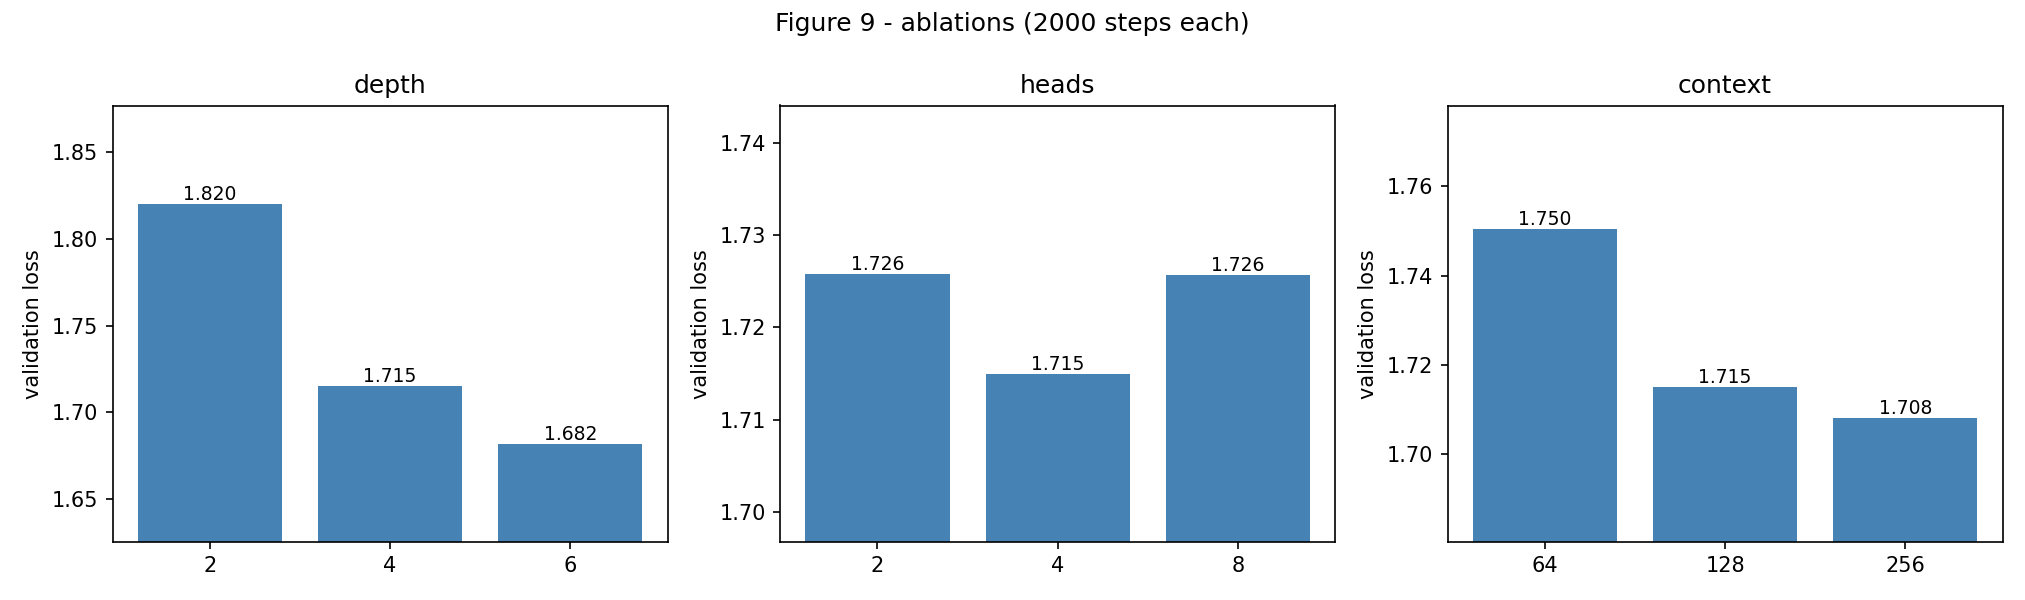

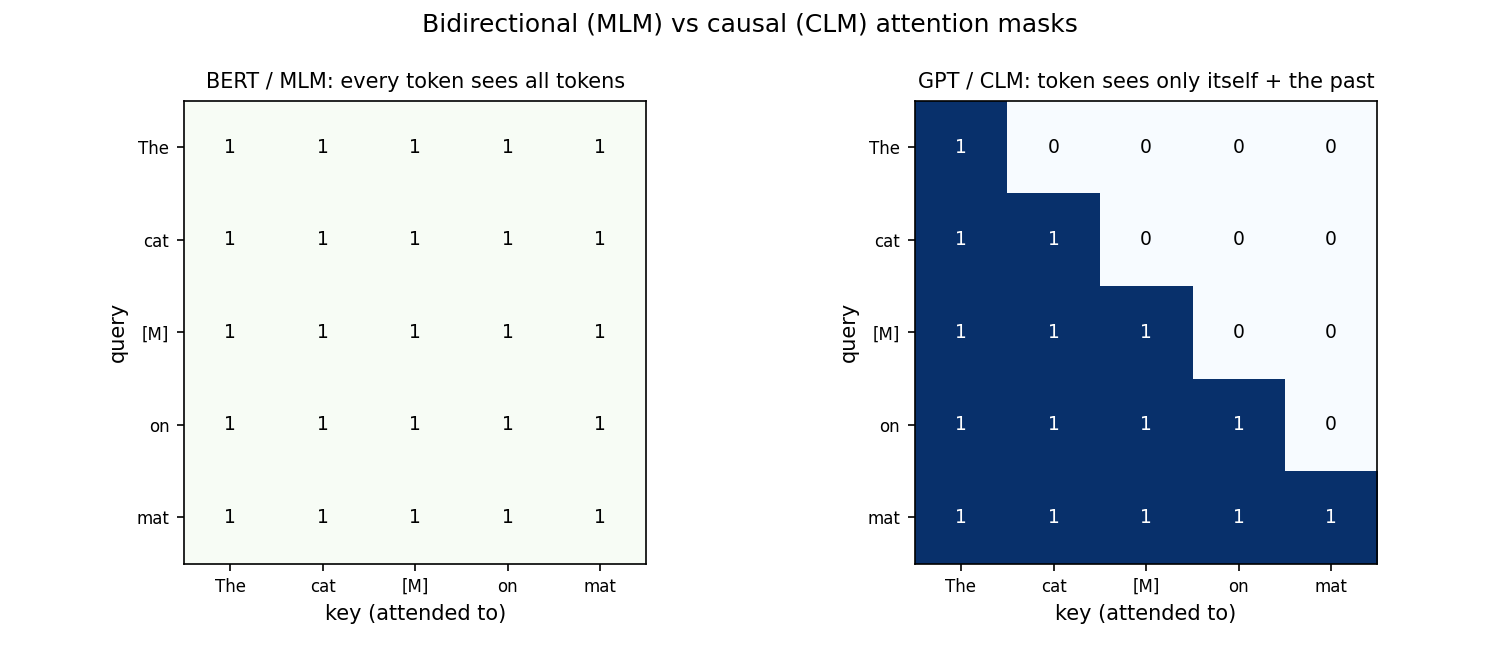

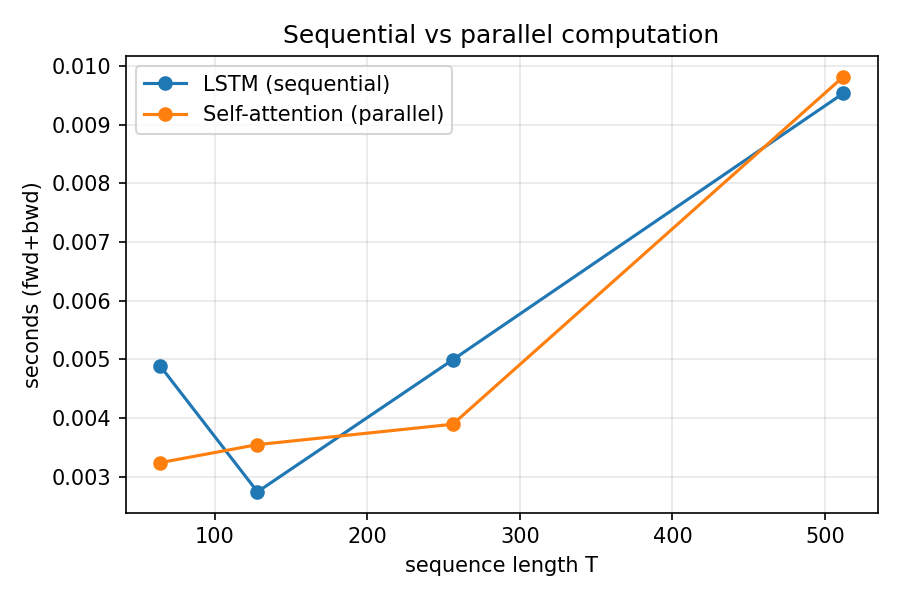

In [15]:
from IPython.display import Image, display
for f in ['fig9_ablation','mlm_vs_clm_masks','seq_vs_parallel']:
    display(Image(f'outputs/figures/{f}.png'))

In [16]:
!zip -rq outputs.zip outputs
from google.colab import files
files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
!python -m experiments.ablation --experiments position --steps 2000
!cat outputs/logs/ablation_table.md


>>> position = sinusoidal
{'experiment': 'position', 'value': 'sinusoidal', 'params': 3192832, 'train_loss': 1.5411, 'val_loss': 1.715, 'perplexity': 5.56, 'train_time_s': 166.5, 'tokens_per_s': 98400, 'peak_mem_mb': 794}

>>> position = learned
{'experiment': 'position', 'value': 'learned', 'params': 3225600, 'train_loss': 1.6245, 'val_loss': 1.7889, 'perplexity': 5.98, 'train_time_s': 166.2, 'tokens_per_s': 98592, 'peak_mem_mb': 806}

| experiment | value | params | train loss | val loss | perplexity | time (s) | tokens/s | peak mem (MB) |
|---|---|---|---|---|---|---|---|---|
| position | sinusoidal | 3,192,832 | 1.5411 | 1.715 | 5.56 | 166.5 | 98400 | 794 |
| position | learned | 3,225,600 | 1.6245 | 1.7889 | 5.98 | 166.2 | 98592 | 806 |
saved outputs/figures/fig9_ablation.png
| experiment | value | params | train loss | val loss | perplexity | time (s) | tokens/s | peak mem (MB) |
|---|---|---|---|---|---|---|---|---|
| position | sinusoidal | 3,192,832 | 1.5411 | 1.715 | 5.56 | 